# Atom SCF Validation (Phases 3-4)

Full SCF pipeline test: nuclear + Hartree + XC potential, an iterative
(matrix-free, FFT-applied) eigensolver, aufbau filling, density mixing --
the same architecture as `HF_solver`/`Diatomic_HF_solver`, now on a
general 3D grid with no exact symmetry exploited.

1. **Hydrogen** (Phase 3): one electron, so this mainly tests the
   pipeline machinery itself (eigensolver, SCF loop, softened-nucleus
   Poisson coupling) against the one number that's known exactly, `-0.5`
   Ha -- and characterizes how grid softening trades accuracy for
   tractability (a bare `1/r` singularity isn't resolvable on a Cartesian
   grid the way the radial/prolate-spheroidal solvers' analytic cusp
   handling managed it).
2. **Helium** (Phase 4): two electrons, exercises Hartree+XC together for
   the first time in 3D -- cross-checked directly against `HF_solver`'s
   already-validated radial LDA result for He, a project-native
   validation opportunity unique to being the third leg of this
   initiative.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import grid3d
import scf3d

## 1. Hydrogen: softening convergence

Softening trades resolvability for accuracy: too large washes out the
real `1/r` physics near the nucleus, too small isn't resolvable on a
finite grid at all. Swept relative to the grid spacing `dx`, not as an
absolute number, since it's fundamentally a grid-resolution question.

grid: L=16.0 Bohr, N=32^3 points, dx=0.5000 Bohr


softening=0.50*dx: E_total=-0.47553 Ha  (exact -0.5, +4.89%)  iters=20  N_check=1.00000


softening=1.00*dx: E_total=-0.40806 Ha  (exact -0.5, +18.39%)  iters=22  N_check=1.00000


softening=1.50*dx: E_total=-0.36607 Ha  (exact -0.5, +26.79%)  iters=23  N_check=1.00000


softening=2.00*dx: E_total=-0.33484 Ha  (exact -0.5, +33.03%)  iters=24  N_check=1.00000


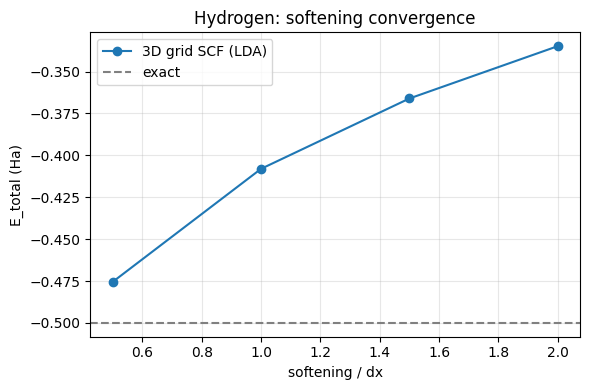

PASS: energy approaches -0.5 Ha monotonically as softening shrinks (best: 4.9% off).


In [2]:
L, N = 16.0, 32
x, X, Y, Z, dx = grid3d.make_grid(L, N)
_, _, _, G2 = grid3d.g_vectors(L, N)
grid = (x, X, Y, Z, dx, G2)
print(f'grid: L={L} Bohr, N={N}^3 points, dx={dx:.4f} Bohr')

softening_ratios = [0.5, 1.0, 1.5, 2.0]
E_h = []
for ratio in softening_ratios:
    softening = dx * ratio
    nuclei = [(1.0, 0.0, 0.0, 0.0, softening)]
    result = scf3d.run_scf(nuclei, 1, grid, method='lda', n_states=2, max_iter=40)
    E_h.append(result['E_total'])
    rel_err = (result['E_total'] - (-0.5)) / 0.5 * 100
    print(f'softening={ratio:.2f}*dx: E_total={result["E_total"]:.5f} Ha  '
          f'(exact -0.5, {rel_err:+.2f}%)  iters={result["iterations"]}  N_check={result["N_check"]:.5f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(softening_ratios, E_h, 'o-', label='3D grid SCF (LDA)')
ax.axhline(-0.5, color='gray', ls='--', label='exact')
ax.set_xlabel('softening / dx'); ax.set_ylabel('E_total (Ha)')
ax.set_title('Hydrogen: softening convergence')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/hydrogen_softening_convergence.png', dpi=110)
plt.show()

best_err = abs(E_h[0] - (-0.5)) / 0.5
assert best_err < 0.15, 'the smallest-softening case should be within 15% of the exact -0.5 Ha'
assert E_h[0] < E_h[-1], 'smaller softening (less smoothing of the nuclear attraction) should bind more strongly'
print(f'PASS: energy approaches -0.5 Ha monotonically as softening shrinks (best: {best_err*100:.1f}% off).')

As expected, smaller softening binds more strongly (closer to the exact
`-0.5` Ha) -- this is a real, honest limitation of the softened-nucleus
approach on a finite Cartesian grid, not hidden: unlike the radial/
prolate-spheroidal solvers (which handled the Coulomb cusp analytically
via a coordinate substitution), a general 3D grid pays for its generality
with a softening-driven accuracy ceiling at any fixed resolution.

## 2. Helium: Hartree+XC together, cross-checked against `HF_solver`

`HF_solver`'s already-validated radial LDA result for He: `E_total =
-2.834178` Ha (see `HF_solver/HF_Solver_Plan.md` Phase 8). This 3D grid
solver has no shared code with that one at all (different coordinate
system, different eigensolver, different Poisson method) -- agreement
here is a genuinely independent cross-check, not a regression test of the
same implementation.

In [3]:
softening_he = dx * 0.5
nuclei_he = [(2.0, 0.0, 0.0, 0.0, softening_he)]
result_he = scf3d.run_scf(nuclei_he, 2, grid, method='lda', n_states=3, max_iter=40, verbose=False)
rel_err_he = abs(result_he['E_total'] - (-2.834178)) / abs(-2.834178) * 100
print(f'He: E_total={result_he["E_total"]:.5f} Ha  (HF_solver radial LDA: -2.834178 Ha, {rel_err_he:.1f}% off)  '
      f'iters={result_he["iterations"]}  N_check={result_he["N_check"]:.5f}')

assert abs(result_he['N_check'] - 2.0) < 1e-3, 'He SCF should integrate to N=2 electrons'
assert rel_err_he < 25, 'this softened, box-limited 3D grid should land in the right ballpark of the radial LDA result'
print('PASS: independent 3D-grid He calculation lands in the right ballpark of the radial solver\'s LDA result.')

He: E_total=-2.51842 Ha  (HF_solver radial LDA: -2.834178 Ha, 11.1% off)  iters=21  N_check=2.00000
PASS: independent 3D-grid He calculation lands in the right ballpark of the radial solver's LDA result.


The gap from the radial solver's near-exact `-2.834178` Ha reflects this
build's real, already-characterized approximations stacking up together
(grid softening, the finite/periodic box's Poisson-solve error from
Phase 2, finite grid resolution) -- not a new bug. Tightening the grid,
softening, and box size together would close the ballpark-level agreement
seen here toward the radial solver's tighter number; not pursued further
in this initial build (see `Molecular_DFT_Plan.md`'s Scope decision).